In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
tf.get_logger().setLevel('ERROR')
tf.keras.utils.set_random_seed(42)

## Task 1

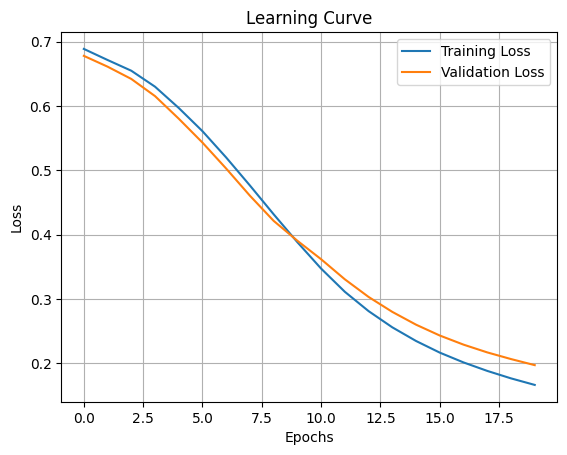

Final train loss: 0.1664
Final val loss: 0.1971
Verdict: Good Fit


In [2]:
x = np.random.rand(1000, 10)
y = (np.sum(x, axis=1) > 5).astype(int)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x, y, epochs=20, batch_size=32, validation_split=0.2, verbose=0)

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

gap = val_loss[-1] - train_loss[-1]
if train_loss[-1] > 0.5 and val_loss[-1] > 0.5:
    verdict = 'Underfitting'
elif gap > 0.1:
    verdict = 'Overfitting'
else:
    verdict = 'Good Fit'
print('Final train loss:', round(train_loss[-1], 4))
print('Final val loss:', round(val_loss[-1], 4))
print('Verdict:', verdict)

## Task 2

In [3]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []
for i, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    model = LogisticRegression(max_iter=200)
    model.fit(X[train_idx], y[train_idx])
    pred = model.predict(X[test_idx])
    acc = accuracy_score(y[test_idx], pred)
    scores.append(acc)
    print('Fold', i, 'accuracy:', round(acc, 4))

print('\nAverage accuracy:', round(sum(scores)/len(scores), 4))

Fold 1 accuracy: 1.0
Fold 2 accuracy: 1.0


Fold 3 accuracy: 0.9333
Fold 4 accuracy: 0.9667
Fold 5 accuracy: 0.9667

Average accuracy: 0.9733


## Task 3

In [4]:
x = np.random.rand(1000, 10)
y = (np.sum(x, axis=1) > 5).astype(int)
y = np.where(np.random.rand(len(y)) < 0.15, 1 - y, y)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x, y,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

epochs_run = len(history.history['loss'])
best_epoch = int(np.argmin(history.history['val_loss'])) + 1
print('Training stopped at epoch:', epochs_run)
print('Best epoch:', best_epoch)
print('Best val_loss:', round(min(history.history['val_loss']), 4))

Training stopped at epoch: 13
Best epoch: 10
Best val_loss: 0.5187


## Task 4

Without Dropout - train acc: 0.9712 val acc: 0.915 gap: 0.0562
With Dropout    - train acc: 0.875 val acc: 0.875 gap: 0.0


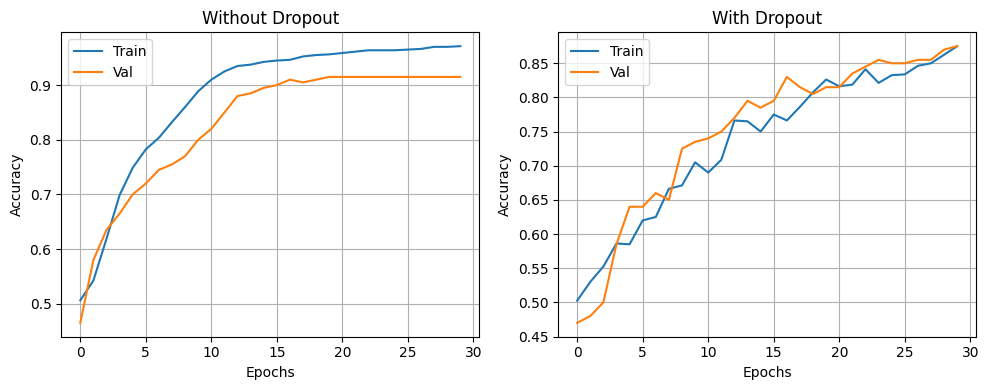

In [16]:
x = np.random.rand(1000, 10)
y = (np.sum(x, axis=1) > 5).astype(int)

def make(dropout=False):
    layers = [tf.keras.layers.Input(shape=(10,)),
              tf.keras.layers.Dense(64, activation='relu')]
    if dropout:
        layers.append(tf.keras.layers.Dropout(0.5))
    layers.append(tf.keras.layers.Dense(32, activation='relu'))
    if dropout:
        layers.append(tf.keras.layers.Dropout(0.3))
    layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))
    m = tf.keras.Sequential(layers)
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_no = make(dropout=False)
hist_no = model_no.fit(x, y, epochs=30, batch_size=32, validation_split=0.2, verbose=0)

model_dp = make(dropout=True)
hist_dp = model_dp.fit(x, y, epochs=30, batch_size=32, validation_split=0.2, verbose=0)

print('Without Dropout - train acc:', round(hist_no.history['accuracy'][-1], 4),
      'val acc:', round(hist_no.history['val_accuracy'][-1], 4),
      'gap:', round(hist_no.history['accuracy'][-1] - hist_no.history['val_accuracy'][-1], 4))
print('With Dropout    - train acc:', round(hist_dp.history['accuracy'][-1], 4),
      'val acc:', round(hist_dp.history['val_accuracy'][-1], 4),
      'gap:', round(hist_dp.history['accuracy'][-1] - hist_dp.history['val_accuracy'][-1], 4))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_no.history['accuracy'], label='Train')
plt.plot(hist_no.history['val_accuracy'], label='Val')
plt.title('Without Dropout')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_dp.history['accuracy'], label='Train')
plt.plot(hist_dp.history['val_accuracy'], label='Val')
plt.title('With Dropout')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

## Task 5

Stopped at epoch: 107
Final train acc: 0.9083
Final val acc: 0.9667


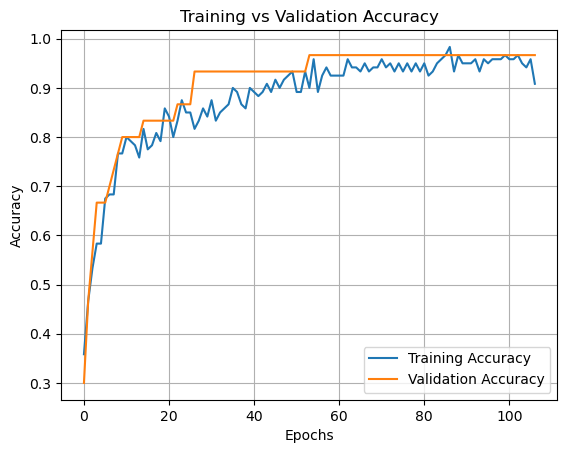

Fold 1 accuracy: 1.0
Fold 2 accuracy: 0.9667
Fold 3 accuracy: 0.9667


In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.utils import shuffle

data = load_iris()
X, y = data.data, data.target
X = StandardScaler().fit_transform(X)
X, y = shuffle(X, y, random_state=42)

def build_model():
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(3, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model = build_model()
history = model.fit(X, y, epochs=200, batch_size=16, validation_split=0.2,
                    callbacks=[early_stop], verbose=0)

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
print('Stopped at epoch:', len(train_acc))
print('Final train acc:', round(train_acc[-1], 4))
print('Final val acc:', round(val_acc[-1], 4))

plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
for i, (tr, te) in enumerate(kf.split(X), 1):
    Xtr, ytr = shuffle(X[tr], y[tr], random_state=i)
    m = build_model()
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    m.fit(Xtr, ytr, epochs=200, batch_size=16, validation_split=0.2,
          callbacks=[es], verbose=0)
    _, acc = m.evaluate(X[te], y[te], verbose=0)
    fold_scores.append(acc)
    print('Fold', i, 'accuracy:', round(acc, 4))

avg = float(np.mean(fold_scores))
print('\nAverage CV accuracy:', round(avg, 4))

gap = train_acc[-1] - val_acc[-1]
if val_acc[-1] < 0.6:
    verdict = 'Underfitting'
elif gap > 0.15:
    verdict = 'Overfitting'
else:
    verdict = 'Generalizes well'
print('Verdict:', verdict)